<a href="https://colab.research.google.com/github/miaflynn/CYPLAN255-Final-Project/blob/Mia/03b_visualizations_businesstype_RDE.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install contextily

In [2]:
import pandas as pd
import geopandas as gpd
import numpy as np
import plotly.graph_objects as go

#added more that we use in lab
import os
%matplotlib inline
import matplotlib.pyplot as plt
from shapely.geometry import LineString

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
!ls /content/drive
!ls /content/drive/Shareddrives

MyDrive  Shareddrives


In [5]:
df = pd.read_csv('/content/drive/MyDrive/C255_final_project/cleaned/rbl_rde_cleaned.csv')

In [6]:
df['location_start_date'] = pd.to_datetime(df['location_start_date'], errors='coerce')
df['location_end_date'] = pd.to_datetime(df['location_end_date'], errors='coerce')

#creating two dataframes to represent businesses opening/closing within our timeframe (businesses opening 2016 onwards and businesses closing pre-2026)

df_filtered_start = df[
    (df['location_start_date'] >= '2016-01-01') &
    (df['location_start_date'] < '2026-01-01')
].copy()

df_filtered_end = df[
    (df['location_end_date'] < '2026-01-01') &
    (df['location_end_date'] >= '2016-01-01')
].copy()

In [7]:
#converting values to datetime and creating a new column for the necessary year
df_filtered_start['location_start_date'] = pd.to_datetime(df_filtered_start['location_start_date'], errors='coerce')
df_filtered_end['location_end_date'] = pd.to_datetime(df_filtered_end['location_end_date'], errors='coerce')

df_filtered_start['open_year'] = df_filtered_start['location_start_date'].dt.year
df_filtered_end['close_year'] = df_filtered_end['location_end_date'].dt.year

In [8]:
# Counting openings and closings by year
openings_rde = df_filtered_start.groupby('open_year').size()
closings_rde = df_filtered_end.groupby('close_year').size()

# Combining into one dataframe
net = pd.DataFrame({
    'openings': openings_rde,
    'closings': closings_rde
}).fillna(0)

# Calculating net change
net['net_openings'] = net['openings'] - net['closings']

# Sorting by year
net = net.sort_index()

# plt.figure()
# plt.plot(net.index, net['net_openings'], marker='o', color='blue')
# plt.xlabel('Year')
# plt.ylabel('Net Openings (Openings - Closings)')
# plt.title('Net RDE Business Openings Over Time in San Francisco')
# plt.axhline(0, color='gray')
# plt.show()

In [9]:

df_filtered_end['business_end_date'] = pd.to_datetime(df_filtered_end['business_end_date'], errors='coerce')

# Combining openings and closings
bars = pd.DataFrame({
    'openings': openings_rde,
    'closings': closings_rde
}).fillna(0)

# Making closings negative
bars['closings'] = -bars['closings']

# Sorting by year
bars = bars.sort_index()

# plt.figure()
# plt.bar(bars.index, bars['openings'], label='Openings', color='blue')
# plt.bar(bars.index, bars['closings'], label='Closings', color='orange')
# plt.xlabel('Year')
# plt.ylabel('No. of Businesses')
# plt.title('RDE Business Openings and Closings in San Francisco')
# plt.legend()
# plt.show()

In [10]:
#sanity checking values

openings = df_filtered_start.groupby('open_year').size()
openings

,0
open_year,
2016,3848
2017,5421
2018,5839
2019,5989
2020,4679
2021,3806
2022,3125
2023,3204
2024,2629


In [11]:
#Set up naics code descriptions to print and remove errant 2026 values
openings_by_type = df_filtered_start.groupby(['open_year', 'naics_code_description']).size().unstack(fill_value=0)
openings_by_type = openings_by_type[openings_by_type.index < 2026]

colors = ['blue', 'orange', 'green', 'purple']

# plt.figure(figsize=(12, 6))

# for i, business_type in enumerate(openings_by_type.columns):
#     plt.plot(
#         openings_by_type.index,
#         openings_by_type[business_type],
#         marker='o',
#         label=business_type,
#         color=colors[i % len(colors)]
#     )
# plt.title('Business Openings Over Time by Business Type')
# plt.xlabel('Year')
# plt.ylabel('Number of Openings')
# plt.legend(title='Business Type', bbox_to_anchor=(1.05, 1), loc='upper left')
# plt.tight_layout()
# plt.show()

In [12]:
#Same thing for business closings
#Set up naics code descriptions to print and remove errant 2026 values
closings_by_type = df_filtered_end.groupby(['close_year', 'naics_code_description']).size().unstack(fill_value=0)
closings_by_type = closings_by_type[closings_by_type.index < 2026]

# plt.figure(figsize=(12, 6))

# for i, business_type in enumerate(closings_by_type.columns):
#     plt.plot(
#         closings_by_type.index,
#         closings_by_type[business_type],
#         marker='o',
#         label=business_type,
#         color=colors[i % len(colors)]
#     )

# plt.title('Business Closings Over Time by Business Type')
# plt.xlabel('Year')
# plt.ylabel('Number of Closings')
# plt.legend(title='Business Type', bbox_to_anchor=(1.05, 1), loc='upper left')
# plt.tight_layout()
# plt.show()

In [13]:
# Combine openings and closings again
pct_df = pd.DataFrame({
    'openings': openings_rde,
    'closings': closings_rde
}).fillna(0)

pct_df = pct_df.sort_index()

# Keep only 2016–2025
pct_df = pct_df[(pct_df.index >= 2016) & (pct_df.index < 2026)]

In [14]:
baseline_open = pct_df.loc[2016, 'openings']
baseline_close = pct_df.loc[2016, 'closings']

pct_df['openings_pct_change'] = ((pct_df['openings'] - baseline_open) / baseline_open) * 100
pct_df['closings_pct_change'] = ((pct_df['closings'] - baseline_close) / baseline_close) * 100

In [15]:
# plt.figure(figsize=(10, 6))

# plt.plot(pct_df.index, pct_df['openings_pct_change'], marker='o', label='Openings % Change')
# plt.plot(pct_df.index, pct_df['closings_pct_change'], marker='o', label='Closings % Change')

# plt.axhline(0)  # baseline reference
# plt.xlabel('Year')
# plt.ylabel('Percent Change from 2016 (%)')
# plt.title('Percent Change in Business Openings and Closings (Baseline = 2016)')
# plt.legend()
# plt.show()

In [16]:
plt.figure(figsize=(10, 6))

# Plot percent changes
# plt.plot(pct_df.index, pct_df['openings_pct_change'], marker='o', label='Openings % Change')
# plt.plot(pct_df.index, pct_df['closings_pct_change'], marker='o', label='Closings % Change')

# # Net difference in percent change
# pct_df['net_pct_diff'] = pct_df['openings_pct_change'] - pct_df['closings_pct_change']

# plt.plot(pct_df.index, pct_df['net_pct_diff'], linestyle='--', linewidth=2, label='Net % Difference')

# plt.axhline(0)
# plt.xlabel('Year')
# plt.ylabel('Percent Change from 2016 (%)')
# plt.title('Percent Change in Openings and Closings (Baseline = 2016)')
# plt.legend()

# plt.show()

<Figure size 1000x600 with 0 Axes>

<Figure size 1000x600 with 0 Axes>

In [17]:
plt.figure(figsize=(10, 6))

# Plot percent changes
# plt.plot(pct_df.index, pct_df['openings_pct_change'], marker='o', label='Openings % Change')
# plt.plot(pct_df.index, pct_df['closings_pct_change'], marker='o', label='Closings % Change')

# # Net difference in percent change
# pct_df['net_pct_diff'] = pct_df['openings_pct_change'] - pct_df['closings_pct_change']

# plt.plot(pct_df.index, pct_df['net_pct_diff'], linestyle='--', linewidth=2, label='Net % Difference')

# plt.axhline(0)
# plt.xlabel('Year')
# plt.ylabel('Percent Change from 2016 (%)')
# plt.title('Percent Change in Openings and Closings (Baseline = 2016)')
# plt.legend()

# plt.show()

<Figure size 1000x600 with 0 Axes>

<Figure size 1000x600 with 0 Axes>

In [18]:
df_sf = pd.read_csv('/content/drive/MyDrive/C255_final_project/cleaned/rbl_total_cleaned.csv')

In [19]:
df_sf['location_start_date'] = pd.to_datetime(df_sf['location_start_date'], errors='coerce')
df_sf['location_end_date'] = pd.to_datetime(df_sf['location_end_date'], errors='coerce')

#creating two dataframes to represent businesses opening/closing within our timeframe (businesses opening 2016 onwards and businesses closing pre-2026)

df_filtered_start_sf = df_sf[
    (df_sf['location_start_date'] >= '2016-01-01') &
    (df_sf['location_start_date'] < '2026-01-01')
]
df_filtered_end_sf = df_sf[
    (df_sf['location_end_date'] < '2026-01-01') &
    (df_sf['location_end_date'] >= '2016-01-01')
]

In [20]:
df_sf = df_sf[
    df_sf['lat'].notna() &
    df_sf['lon'].notna() &
    (df_sf['lat'] != 0) &
    (df_sf['lon'] != 0)
].copy()

In [21]:
#converting values to datetime and creating a new column for the necessary year
df_filtered_start_sf['location_start_date'] = pd.to_datetime(df_filtered_start_sf['location_start_date'], errors='coerce')
df_filtered_end_sf['location_end_date'] = pd.to_datetime(df_filtered_end_sf['location_end_date'], errors='coerce')

df_filtered_start_sf['open_year'] = df_filtered_start_sf['location_start_date'].dt.year
df_filtered_end_sf['close_year'] = df_filtered_end_sf['location_end_date'].dt.year

In [22]:
openings_sf = df_filtered_start_sf.groupby('open_year').size()
closings_sf = df_filtered_end_sf.groupby('close_year').size()

# Combine openings and closings again
pct_df_sf = pd.DataFrame({
    'openings_sf': openings_sf,
    'closings_sf': closings_sf
}).fillna(0)

pct_df_sf = pct_df_sf.sort_index()

# Keep only 2016–2025
pct_df_sf = pct_df_sf[(pct_df_sf.index >= 2016) & (pct_df_sf.index < 2026)]

In [23]:
#Set up naics code descriptions to print and remove errant 2026 values
openings_by_type_sf = df_filtered_start_sf.groupby(['open_year', 'naics_code_description']).size().unstack(fill_value=0)
openings_by_type_sf = openings_by_type_sf[openings_by_type_sf.index < 2026]

# plt.figure(figsize=(12, 6))

# for i, business_type in enumerate(openings_by_type_sf.columns):
#     plt.plot(
#         openings_by_type_sf.index,
#         openings_by_type_sf[business_type],
#         marker='o',
#         label=business_type,
#     )
# plt.title('Business Openings Over Time by Business Type')
# plt.xlabel('Year')
# plt.ylabel('Number of Openings')
# plt.legend(title='Business Type', bbox_to_anchor=(1.05, 1), loc='upper left')
# plt.tight_layout()
# plt.show()

In [24]:
rde_naics = df['naics_code'].dropna().unique()
df_sf_non_rde = df_sf[~df_sf['naics_code'].isin(rde_naics)].copy()

df_filtered_start_non_rde = df_sf_non_rde[
    (df_sf_non_rde['location_start_date'] >= '2016-01-01') &
    (df_sf_non_rde['location_start_date'] < '2026-01-01')
].copy()

df_filtered_start_non_rde['open_year'] = pd.to_datetime(
    df_filtered_start_non_rde['location_start_date'],
    errors='coerce'
).dt.year

In [25]:
# RDE openings
rde_openings = df_filtered_start.groupby('open_year').size()

# All SF openings
sf_openings = df_filtered_start_non_rde.groupby('open_year').size()

# Combine into one dataframe
compare_df = pd.DataFrame({
    'rde_openings': rde_openings,
    'sf_openings': sf_openings
}).fillna(0)

# Sort and limit years
compare_df = compare_df.sort_index()
compare_df = compare_df[(compare_df.index >= 2016) & (compare_df.index < 2026)]

# Create NON-RDE
compare_df['non_rde_openings'] = compare_df['sf_openings'] - compare_df['rde_openings']

# Percent change from 2016 baseline
baseline_rde = compare_df.loc[2016, 'rde_openings']
baseline_non_rde = compare_df.loc[2016, 'non_rde_openings']

compare_df['rde_pct_change'] = ((compare_df['rde_openings'] - baseline_rde) / baseline_rde) * 100
compare_df['non_rde_pct_change'] = ((compare_df['non_rde_openings'] - baseline_non_rde) / baseline_non_rde) * 100

# plt.figure(figsize=(10, 6))

# plt.plot(compare_df.index, compare_df['rde_pct_change'], marker='o', label='RDE Businesses')
# plt.plot(compare_df.index, compare_df['non_rde_pct_change'], marker='o', label='Non-RDE Businesses')

# plt.axhline(0)
# plt.xlabel('Year')
# plt.ylabel('Percent Change from 2016 (%)')
# plt.title('RDE vs Non-RDE Business Openings (% Change, Baseline = 2016)')
# plt.legend()

# plt.show()

In [26]:
# Setting up same thing for net closings

df_filtered_end_non_rde = df_sf_non_rde[
    (df_sf_non_rde['location_end_date'] >= '2016-01-01') &
    (df_sf_non_rde['location_end_date'] < '2026-01-01')
].copy()

df_filtered_end_non_rde['close_year'] = pd.to_datetime(
    df_filtered_end_non_rde['location_end_date'],
    errors='coerce'
).dt.year

In [27]:
# RDE
rde_openings = df_filtered_start.groupby('open_year').size()
rde_closings = df_filtered_end.groupby('close_year').size()

# Non-RDE
non_rde_openings = df_filtered_start_non_rde.groupby('open_year').size()
non_rde_closings = df_filtered_end_non_rde.groupby('close_year').size()

In [28]:
compare_net = pd.DataFrame({
    'rde_openings': rde_openings,
    'rde_closings': rde_closings,
    'non_rde_openings': non_rde_openings,
    'non_rde_closings': non_rde_closings
}).fillna(0)

compare_net = compare_net.sort_index()
compare_net = compare_net[(compare_net.index >= 2016) & (compare_net.index < 2026)]

In [29]:
compare_net['rde_net'] = compare_net['rde_openings'] - compare_net['rde_closings']
compare_net['non_rde_net'] = compare_net['non_rde_openings'] - compare_net['non_rde_closings']

In [30]:
baseline_rde = compare_net.loc[2016, 'rde_net']
baseline_non_rde = compare_net.loc[2016, 'non_rde_net']

compare_net['rde_net_pct_change'] = ((compare_net['rde_net'] - baseline_rde) / abs(baseline_rde)) * 100
compare_net['non_rde_net_pct_change'] = ((compare_net['non_rde_net'] - baseline_non_rde) / abs(baseline_non_rde)) * 100

In [31]:
# plt.figure(figsize=(10, 6))

# plt.plot(compare_net.index, compare_net['rde_net_pct_change'], marker='o', label='RDE Net Change')
# plt.plot(compare_net.index, compare_net['non_rde_net_pct_change'], marker='o', label='Non-RDE Net Change')

# plt.axhline(0)
# plt.xlabel('Year')
# plt.ylabel('Percent Change from 2016 (%)')
# plt.title('RDE vs Non-RDE Net Business Change (% Change, Baseline = 2016)')
# plt.legend()

# plt.show()

In [32]:
tracts_gdf = gpd.read_file(
    "/content/drive/MyDrive/C255_final_project/cb_2020_06_tract_500k"
)

#checking to make sure all good

tracts_gdf.columns

Index(['STATEFP', 'COUNTYFP', 'TRACTCE', 'AFFGEOID', 'GEOID', 'NAME',
       'NAMELSAD', 'STUSPS', 'NAMELSADCO', 'STATE_NAME', 'LSAD', 'ALAND',
       'AWATER', 'geometry'],
      dtype='object')

In [33]:
# simplifying
tracts_gdf = tracts_gdf[["NAME", "NAMELSAD", "STATE_NAME","GEOID", "geometry"]]

In [34]:
# was getting error with "index_right" - so troubleshooted this
tracts_gdf = tracts_gdf.drop(columns=["index_right", ], errors="ignore")
df_sf_non_rde = df_sf_non_rde.drop(columns=["index_right"], errors="ignore")

In [35]:
tracts_gdf = tracts_gdf[
    (tracts_gdf.geometry.centroid.x > -123) &
    (tracts_gdf.geometry.centroid.x < -122) &
    (tracts_gdf.geometry.centroid.y > 37) &
    (tracts_gdf.geometry.centroid.y < 38)
]

/tmp/ipykernel_7523/4079206000.py:2: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  (tracts_gdf.geometry.centroid.x > -123) &
/tmp/ipykernel_7523/4079206000.py:3: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  (tracts_gdf.geometry.centroid.x < -122) &
/tmp/ipykernel_7523/4079206000.py:4: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  (tracts_gdf.geometry.centroid.y > 37) &
/tmp/ipykernel_7523/4079206000.py:5: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before

In [36]:
df_sf.columns

Index(['Unnamed: 0', 'uniqueid', 'business_account_number', 'location_id',
       'ownership_name', 'dba_name', 'street_address', 'city', 'state',
       'source_zipcode', 'business_start_date', 'business_end_date',
       'location_start_date', 'location_end_date', 'administratively_closed',
       'mail_address', 'mail_city', 'mail_state', 'mail_zipcode', 'naics_code',
       'naics_code_description', 'naics_code_descriptions_list', 'lic_code',
       'lic_code_description', 'lic_code_descriptions_list', 'parking_tax',
       'transient_occupancy_tax', 'business_location', 'business_corridor',
       'neighborhoods_analysis_boundaries', 'supervisor_district',
       'community_benefit_district', 'data_as_of', 'data_loaded_at',
       'geometry', 'administratively_closed_bool', 'year', 'status', 'lon',
       'lat'],
      dtype='object')

In [37]:
from shapely.geometry import Point

# create geometry column
df_sf['geometry'] = gpd.points_from_xy(df_sf['lon'], df_sf['lat'])

# convert to GeoDataFrame
gdf_sf = gpd.GeoDataFrame(df_sf, geometry='geometry', crs='EPSG:4326')

In [38]:
tracts_gdf = tracts_gdf.to_crs(gdf_sf.crs)

In [39]:
# keep only San Francisco County tracts
tracts_gdf = tracts_gdf[tracts_gdf['GEOID'].str[2:5] == '075']


In [40]:
gdf_joined = gpd.sjoin(gdf_sf, tracts_gdf, how='left', predicate='within')

In [41]:
# openings
gdf_open = gdf_joined[
    (gdf_joined['location_start_date'] >= '2016-01-01') &
    (gdf_joined['location_start_date'] < '2026-01-01')
].copy()

# closings
gdf_close = gdf_joined[
    (gdf_joined['location_end_date'] >= '2016-01-01') &
    (gdf_joined['location_end_date'] < '2026-01-01')
].copy()

In [42]:
gdf_open['open_year'] = pd.to_datetime(
    gdf_open['location_start_date'], errors='coerce'
).dt.year

gdf_close['close_year'] = pd.to_datetime(
    gdf_close['location_end_date'], errors='coerce'
).dt.year

In [43]:
# count by tract
openings_by_tract = gdf_open.groupby('GEOID').size()
closings_by_tract = gdf_close.groupby('GEOID').size()

tract_counts = pd.DataFrame({
    'openings': openings_by_tract,
    'closings': closings_by_tract
}).fillna(0)

# net change
tract_counts['net'] = tract_counts['openings'] - tract_counts['closings']

In [44]:
tracts_map = tracts_gdf.merge(
    tract_counts,
    on='GEOID',
    how='left'
)

# # fill missing tracts with 0
# tracts_map[['openings', 'closings', 'net']] = tracts_map[
#     ['openings', 'closings', 'net']
# ].fillna(0)

<Axes: >

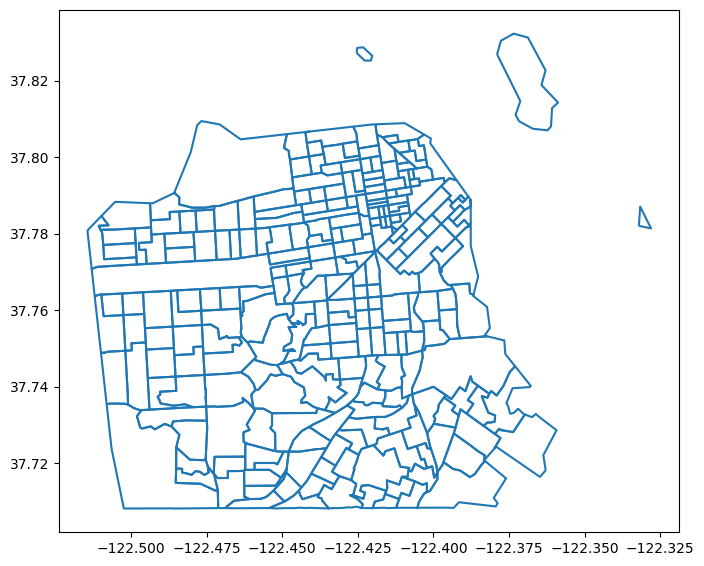

In [45]:
tracts_map.boundary.plot(figsize=(8,8))

In [46]:
# #BUGGY - don't trust

# fig, ax = plt.subplots(1, 1, figsize=(12, 10))

# tracts_map.plot(
#     column='net',
#     cmap='RdBu',   # red = losses, blue = gains
#     legend=True,
#     ax=ax,
#     edgecolor='black',
#     linewidth=0.2
# )

# ax.set_title('Net Business Change by Census Tract (2016–2025)')
# ax.axis('off')

# plt.show()

In [47]:
# Openings by tract + year
openings = (
    gdf_open
    .groupby(['GEOID', 'open_year'])
    .size()
    .reset_index(name='openings')
    .rename(columns={'open_year': 'year'})
)

# Closings by tract + year
closings = (
    gdf_close
    .groupby(['GEOID', 'close_year'])
    .size()
    .reset_index(name='closings')
    .rename(columns={'close_year': 'year'})
)

# Merge openings + closings
tract_year = pd.merge(
    openings,
    closings,
    on=['GEOID', 'year'],
    how='outer'
).fillna(0)

# Net change
tract_year['net'] = tract_year['openings'] - tract_year['closings']


In [48]:
tracts_year_map = tracts_gdf.merge(
    tract_year,
    on='GEOID',
    how='left'
)

tracts_year_map['net'] = tracts_year_map['net'].fillna(0)

In [49]:
vmin = tracts_year_map['net'].min()
vmax = tracts_year_map['net'].max()

# Making it symmetric around zero
abs_max = max(abs(vmin), abs(vmax))

In [50]:
import plotly.express as px
import json

# Convert to GeoJSON
# tracts_year_map = tracts_year_map.to_crs(epsg=4326)

# geojson = json.loads(tracts_year_map.to_json())

# fig = px.choropleth(
#     tracts_year_map,
#     geojson=geojson,
#     locations='GEOID',
#     featureidkey='properties.GEOID',
#     color='net',
#     animation_frame='year',
#     color_continuous_scale='RdBu',
#     range_color=[-abs_max, abs_max]
# )

# fig.update_geos(fitbounds="locations", visible=False)

# fig.show()

In [51]:
# RDE points only
df_rde_map = df[
    df['lat'].notna() &
    df['lon'].notna() &
    (df['lat'] != 0) &
    (df['lon'] != 0)
].copy()

df_rde_map['geometry'] = gpd.points_from_xy(df_rde_map['lon'], df_rde_map['lat'])
gdf_rde = gpd.GeoDataFrame(df_rde_map, geometry='geometry', crs='EPSG:4326')

In [52]:
# make sure tracts match CRS
tracts_gdf = tracts_gdf.to_crs(gdf_rde.crs)

In [53]:
# spatial join
gdf_rde_joined = gpd.sjoin(gdf_rde, tracts_gdf, how='left', predicate='within')

In [54]:
# openings
gdf_open_rde = gdf_rde_joined[
    (gdf_rde_joined['location_start_date'] >= '2016-01-01') &
    (gdf_rde_joined['location_start_date'] < '2026-01-01')
].copy()

In [55]:
# closings
gdf_close_rde = gdf_rde_joined[
    (gdf_rde_joined['location_end_date'] >= '2016-01-01') &
    (gdf_rde_joined['location_end_date'] < '2026-01-01')
].copy()

In [56]:
gdf_open_rde['open_year'] = gdf_open_rde['location_start_date'].dt.year
gdf_close_rde['close_year'] = gdf_close_rde['location_end_date'].dt.year

In [57]:
# tract-year openings
openings_rde = (
    gdf_open_rde
    .groupby(['GEOID', 'open_year'])
    .size()
    .reset_index(name='openings')
    .rename(columns={'open_year': 'year'})
)

In [58]:
# tract-year closings
closings_rde = (
    gdf_close_rde
    .groupby(['GEOID', 'close_year'])
    .size()
    .reset_index(name='closings')
    .rename(columns={'close_year': 'year'})
)

In [59]:
# merge and compute net
tract_year_rde = pd.merge(
    openings_rde,
    closings_rde,
    on=['GEOID', 'year'],
    how='outer'
).fillna(0)

tract_year_rde['net'] = tract_year_rde['openings'] - tract_year_rde['closings']

In [60]:
# join back to tracts
tracts_year_map_rde = tracts_gdf.merge(
    tract_year_rde,
    on='GEOID',
    how='left'
)

tracts_year_map_rde['net'] = tracts_year_map_rde['net'].fillna(0)
tracts_year_map_rde['year'] = tracts_year_map_rde['year'].fillna(2016)

In [61]:
# convert to WGS84 for plotly
tracts_year_map_rde = tracts_year_map_rde.to_crs(epsg=4326)

In [62]:
# symmetric color scale
# abs_max = tract_year_rde['net'].abs().max()

# geojson_rde = json.loads(tracts_year_map_rde.to_json())

# fig = px.choropleth(
#     tracts_year_map_rde,
#     geojson=geojson_rde,
#     locations='GEOID',
#     featureidkey='properties.GEOID',
#     color='net',
#     animation_frame='year',
#     color_continuous_scale='RdBu',
#     range_color=[-abs_max, abs_max],
#     hover_data=['GEOID', 'openings', 'closings', 'net']
# )

# fig.update_geos(fitbounds="locations", visible=False)
# fig.update_layout(title='Net RDE Business Change by Census Tract')
# fig.show()

In [63]:
import plotly.express as px

bubble_map = tracts_year_map_rde.copy()

# make lat/lon
bubble_map = bubble_map.to_crs(epsg=4326)

# creating tract centroids for bubble locations
bubble_map['centroid'] = bubble_map.geometry.centroid
bubble_map['lon'] = bubble_map['centroid'].x
bubble_map['lat'] = bubble_map['centroid'].y

# keep only rows that actually have a year
bubble_map = bubble_map[bubble_map['year'].notna()].copy()

/tmp/ipykernel_7523/1548777126.py:9: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  bubble_map['centroid'] = bubble_map.geometry.centroid


In [64]:
# filling missing counts
bubble_map['openings'] = bubble_map['openings'].fillna(0)
bubble_map['closings'] = bubble_map['closings'].fillna(0)

# separating openings and closings
bubble_long = pd.concat([
    bubble_map[['GEOID', 'year', 'lat', 'lon', 'openings']].rename(columns={'openings': 'count'}).assign(type='Openings'),
    bubble_map[['GEOID', 'year', 'lat', 'lon', 'closings']].rename(columns={'closings': 'count'}).assign(type='Closings')
])

# removing zero-size bubbles
bubble_long = bubble_long[bubble_long['count'] > 0].copy()

In [65]:
# tract_outline = tracts_gdf.to_crs(epsg=4326)

# fig = px.scatter_geo(
#     bubble_long,
#     lat='lat',
#     lon='lon',
#     size='count',
#     color='type',
#     animation_frame='year',
#     hover_name='GEOID',
#     hover_data={'count': True, 'lat': False, 'lon': False},
#     color_discrete_map={
#         'Openings': 'blue',
#         'Closings': 'red'
#     },
#     projection='mercator',
#     title='RDE Business Openings and Closings by Census Tract'
# )

# fig.add_trace(go.Choropleth(
#     geojson=geojson,
#     locations=tract_outline['GEOID'],
#     z=[0] * len(tract_outline),
#     featureidkey='properties.GEOID',
#     colorscale=[[0, 'white'], [1, 'white']],
#     showscale=False,
#     marker_line_color='black',
#     marker_line_width=0.5,
#     hoverinfo='skip'
# ))


# fig.update_geos(
#     fitbounds="locations",
#     visible=False
# )

# fig.show()